# Unified thermal and symmetry Mpemba effects in one Davies process

**Manuscript map.** Sec. IV, Figs. 12-13, Eqs. (80)-(83).

For a symmetry-invariant steady state $\pi$, relative entropy splits as

$$
S(\rho\Vert\pi)
=
\underbrace{S(\rho\Vert\mathcal G[\rho])}_{\text{symmetry breaking}}
+
\underbrace{S(\mathcal G[\rho]\Vert\pi)}_
           {\text{symmetry-respecting athermality}}.
$$

This notebook verifies the identity along a Davies trajectory and
reproduces the two qualitative panels of Fig. 13:

- weak noise $\gamma=0.05$: classical and total thermal crossings;
- strong noise $\gamma=0.25$: only a symmetry crossing.

The same Hamiltonian, bath, optimization target, and free operation are
used in both panels. Only the initial noise strength changes.


In [1]:
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

_TOOLS_DIR = (Path.cwd() / "tools").resolve()
if str(_TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(_TOOLS_DIR))

import notebook_utils as nu

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GREEN = "#3A7D44"
PURPLE = "#7C4D9E"


## 1. Shared TFIM Davies generator

We follow the normalization of the released code,
$s^\alpha=\sigma^\alpha/2$, with $N_s=4$, $J=h=1$, bath inverse
temperature $\beta=2$, and initial inverse temperature $\beta_i=1$.


In [2]:
N_SITES = 4
BETA_BATH = 2.0
BETA_INITIAL = 1.0

hamiltonian = nu.tfim_hamiltonian(
    N_SITES, 1.0, 1.0, spin_half_operators=True
)
L, energies, energy_basis, pi = nu.davies_liouvillian(
    hamiltonian, BETA_BATH
)
eigenvalues, left_vectors = la.eig(L, left=True, right=False)
order = np.argsort(np.abs(eigenvalues.real))
eigenvalues = eigenvalues[order]
left_vectors = left_vectors[:, order]

slow_eigenvalue = eigenvalues[1]
slow_left_mode = nu.unvec(
    left_vectors[:, 1], 2**N_SITES
)
slow_left_mode /= la.norm(slow_left_mode)

print("Slowest nonstationary eigenvalue:", slow_eigenvalue)
assert np.allclose(L @ nu.vec(pi), 0, atol=1e-10)


Slowest nonstationary eigenvalue: (-2.082286287212019-1.3096518783921558e-22j)


## 2. Two noise strengths, one optimization rule

The noisy Gibbs state exactly follows the released script: the random
matrix is multiplied by $\gamma$ before forming $X^\dagger X$, so the
positive perturbation scales as $\gamma^2$. For each $\gamma$, a
fixed-seed local-unitary search minimizes overlap with the same slowest
left mode.


In [3]:
GAMMAS = [0.05, 0.25]
initial_pairs = {}
optimization_histories = {}

for gamma in GAMMAS:
    rho_1 = nu.manuscript_noisy_gibbs_state(
        energies, BETA_INITIAL, gamma, seed=0
    )
    rho_2, rotation, history = nu.minimize_mode_overlap(
        rho_1,
        slow_left_mode,
        N_SITES,
        samples=5_000,
        seed=7 + int(100 * gamma),
    )
    initial_pairs[gamma] = (rho_1, rho_2)
    optimization_histories[gamma] = history
    assert np.allclose(la.eigvalsh(rho_1), la.eigvalsh(rho_2))
    print(
        f"gamma={gamma:.2f}: overlap "
        f"{history[0]:.3e} -> {history[-1]:.3e}"
    )


gamma=0.05: overlap 1.566e-01 -> 1.541e-01


gamma=0.25: overlap 2.234e-01 -> 9.927e-03


## 3. Decomposition along the trajectories

Here $\mathcal G$ is energy dephasing. We evaluate all three terms
independently and assert Eq. (82) at every sampled time, rather than
defining the total as the sum by construction.


In [4]:
times = np.linspace(0, 1, 501)
results = {}

def three_monotones(states):
    symmetry = []
    respecting = []
    total = []
    for state in states:
        twirled = nu.energy_dephase(state)
        symmetry.append(
            nu.asymmetry_relative_entropy(state, twirled)
        )
        respecting.append(
            nu.quantum_relative_entropy(twirled, pi)
        )
        total.append(
            nu.quantum_relative_entropy(state, pi)
        )
    return {
        "symmetry": np.asarray(symmetry),
        "respecting": np.asarray(respecting),
        "total": np.asarray(total),
    }

for gamma, (rho_1, rho_2) in initial_pairs.items():
    states_1 = nu.evolve_density(L, rho_1, times)
    states_2 = nu.evolve_density(L, rho_2, times)
    result_1 = three_monotones(states_1)
    result_2 = three_monotones(states_2)
    results[gamma] = (result_1, result_2)

    for result in (result_1, result_2):
        error = np.max(np.abs(
            result["total"]
            - result["symmetry"]
            - result["respecting"]
        ))
        assert error < 1e-9
    print(f"gamma={gamma:.2f}: decomposition verified.")


gamma=0.05: decomposition verified.


gamma=0.25: decomposition verified.


## 4. Which resource exhibits a Mpemba effect?

Line style labels the two isospectral initial states; color labels the
resource. A crossing is reported only in the direction where the
initially larger curve later becomes smaller.


In [5]:
for gamma, (first, second) in results.items():
    print(f"\ngamma={gamma:.2f}")
    for key in ("symmetry", "respecting", "total"):
        if second[key][0] > first[key][0]:
            tau = nu.crossing_time(times, second[key], first[key])
            direction = "rho_2 starts larger"
        else:
            tau = nu.crossing_time(times, first[key], second[key])
            direction = "rho_1 starts larger"
        print(f"  {key:>10s}: {direction}, tau={tau}")



gamma=0.05
    symmetry: rho_2 starts larger, tau=nan
  respecting: rho_2 starts larger, tau=0.26150114649633016
       total: rho_2 starts larger, tau=0.4258327022615625

gamma=0.25
    symmetry: rho_1 starts larger, tau=0.16649430220699798
  respecting: rho_1 starts larger, tau=nan
       total: rho_1 starts larger, tau=nan


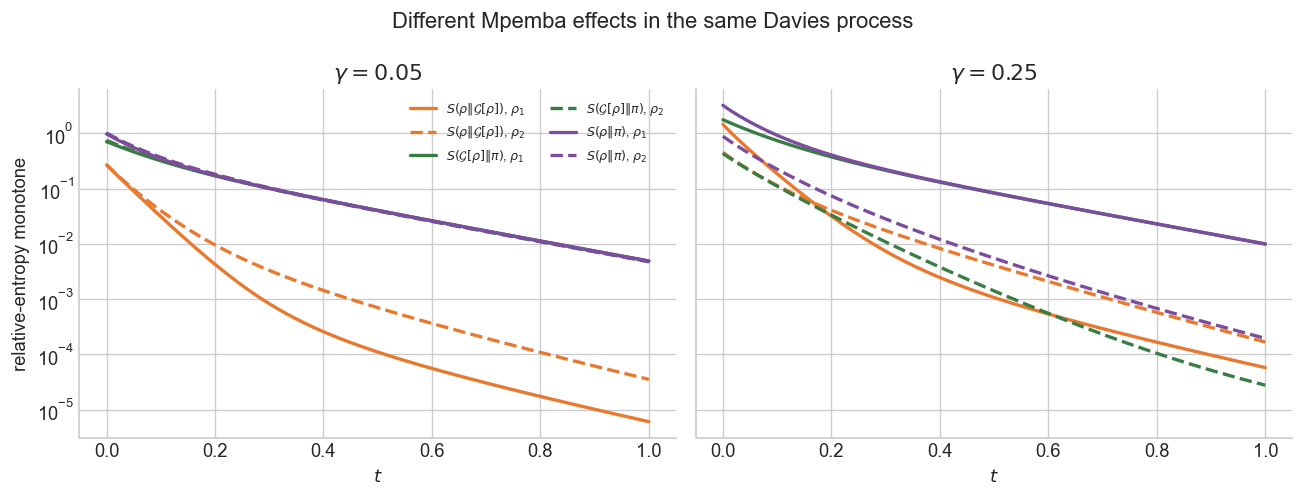

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
colors = {
    "symmetry": ORANGE,
    "respecting": GREEN,
    "total": PURPLE,
}
labels = {
    "symmetry": r"$S(\rho\Vert\mathcal{G}[\rho])$",
    "respecting": r"$S(\mathcal{G}[\rho]\Vert\pi)$",
    "total": r"$S(\rho\Vert\pi)$",
}

for ax, gamma in zip(axes, GAMMAS):
    first, second = results[gamma]
    for key in ("symmetry", "respecting", "total"):
        ax.semilogy(
            times, np.maximum(first[key], 1e-15),
            color=colors[key], lw=2,
            label=labels[key] + r", $\rho_1$",
        )
        ax.semilogy(
            times, np.maximum(second[key], 1e-15),
            color=colors[key], lw=2, ls="--",
            label=labels[key] + r", $\rho_2$",
        )
    ax.set(xlabel=r"$t$", title=fr"$\gamma={gamma}$")

axes[0].set_ylabel("relative-entropy monotone")
axes[0].legend(fontsize=7.6, ncol=2)
fig.suptitle("Different Mpemba effects in the same Davies process")
fig.tight_layout()
plt.show()


## Takeaway

“The Mpemba effect” is not a property of a trajectory without a chosen
resource. The same state pair and physical dynamics can show a crossing
in one component of Eq. (82) and not another. Weak noise produces
crossings in symmetry-respecting and total athermality; strong noise
instead makes the original state the more asymmetric one and yields only
a symmetry-restoration crossing.
